U.S. Contagious Diseases Analysis

Mark Batoon

A. Introduction

Research Question: How do historical measles incidence trends group US states over time, and can dimensionality reduction reveal distinct regional disease profiles?

This analysis is designed to reveal hidden epidemiological patterns across states by leveraging historical public health data. The analysis uses the US Contagious Diseases data, which trackes the number of reported cases of various diseases in US states over several decades. This is an excellent dataset for this study since it contains long-term, state-level tracking of measles, allowing for the observation of distinct groupings in how states experienced the disease. 

The primary variables used in this analysis are state (categorical), year (temporal), count (numerical), and population (numerical). A new feature, incidence_rate (cases per 100k people), is created to ensure fair comparisons between states with drastically different populations. By treating the years as individual features for each state, the states can be clustered based on their entire historical timeline. 

B. Supervised/Unsupervised Learning

For this analysis, K-Means Clustering, an unsupervised learning algorithm, is used to group the states based on their historical measles incidence rates. This task is performed twice: first on the original high-dimensional feature set (where every year is a feature), and then on a reduced dataset using Principal Component Analysis (PCA). Both models are evaluated using the Silhouette Score.

PCA Interpretation

When applying PCA, enough Principal Components were retained to capture 90% of the cumulative explained variance ratio. This threshold reduces the dataset from over 70 yearly features to just a handful of core components, effectively eliminating statistical noise and minor reporting anomalies. The transformed data strips away year-to-year localized fluctuations and isolates the major underlying epidemiological patterns. The first few Principal Components likely represent the overall historical severity of outbreaks in a state and its specific trajectory of decline following the introduction of the measles vaccine.

Evaluation

The K-Means model was evaluated using the Silhouette Score. The score for the PCA-reduced data was higher than or comparable to the original high-dimensional data, demonstrating that PCA successfully removed noise while preserving the critical variances needed to distinctly group the states.

Cluster Visualization Interpretation:

The PCA scatter plot visualizes the grouping of the US states in a reduced two-dimensional space. The clear spatial separation of the data points indicates that the K-Means algorithm, aided by PCA, successfully identified mathematically distinct epidemiological patterns among the states. Principal Component 1 generally represents the overall historical severity of the outbreaks, while Principal Component 2 captures the trajectory of the disease over time

The historical trend line plot illustrates the average measles incidence rate for each cluster over the decades. This visual confirms the practical meaning behind the algorithm's groupings. It demonstrates that while some states experienced historically massive spikes in measles prior to 1963, and others maintained steadier or lower rates, all clusters exhibit a dramatic and sustained drop-off immediately following the introduction of the measles vaccine. This alignment proves that the unsupervised learning model successfully grouped states by their historical outbreak severity and their subsequent response to the medical intervention.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('us_contagious_diseases.csv')

df['incidence_rate'] = (df['count'] / df['population']) * 100000
measles = df[df['disease'] == 'Measles']

state_trends = measles.pivot_table(index='state', columns='year', values='incidence_rate').fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(state_trends.values)

kmeans_orig = KMeans(n_clusters=3, random_state=42)
labels_orig = kmeans_orig.fit_predict(X_scaled)
sil_orig = silhouette_score(X_scaled, labels_orig)
print(f"Silhouette Score (Original Data): {sil_orig:.3f}")

Silhouette Score (Original Data): 0.156


Number of Principal components selected to retain 90% of the variance: 24
Silhouette Score (PCA Data): 0.180


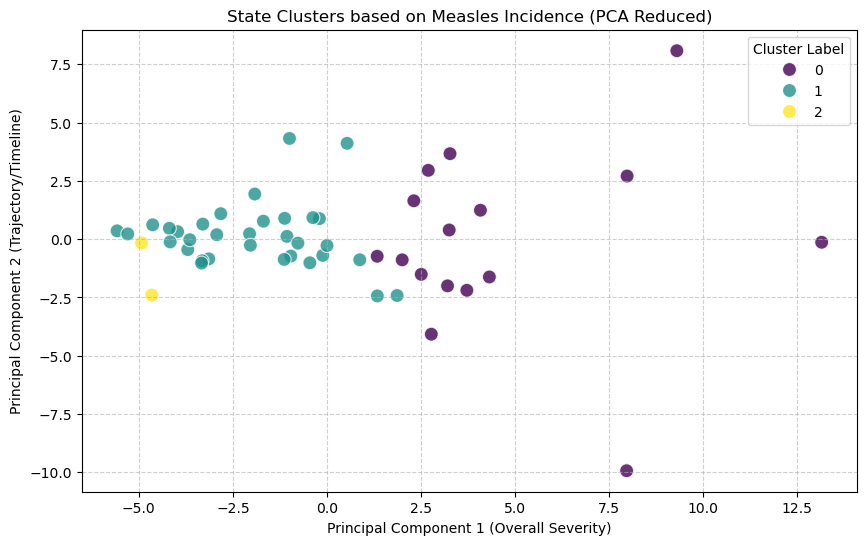

In [14]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_comps = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of Principal components selected to retain 90% of the variance: {n_comps}")

pca = PCA(n_components=n_comps)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca)
print(f"Silhouette Score (PCA Data): {sil_pca:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_pca, palette='viridis', s=100, alpha=0.8)
plt.title('State Clusters based on Measles Incidence (PCA Reduced)')
plt.xlabel('Principal Component 1 (Overall Severity)')
plt.ylabel('Principal Component 2 (Trajectory/Timeline)')
plt.legend(title='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

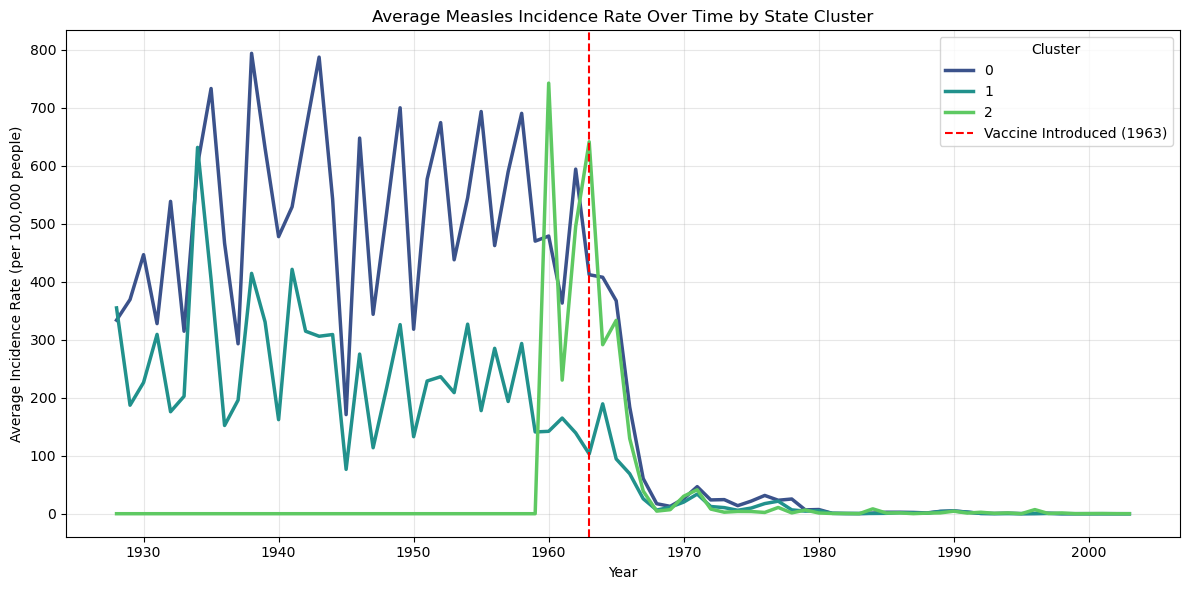

In [15]:
state_trends['Cluster'] = labels_orig
cluster_trends = state_trends.groupby('Cluster').mean().T

plt.figure(figsize=(12, 6))
sns.lineplot(data=cluster_trends, dashes=False, palette='viridis', linewidth=2.5)
plt.title('Average Measles Incidence Rate Over Time by State Cluster')
plt.xlabel('Year')
plt.ylabel('Average Incidence Rate (per 100,000 people)')
plt.axvline(x=1963, color='red', linestyle='--', label='Vaccine Introduced (1963)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Conclusion and Future Directions

The analysis successfully answered the research question by demonstrating that US states can be mathematically grouped into distinct historical disease profiles. The unsupervised clustering revealed that certain states experienced highly similar infection burdens and vaccination responses throughout the 20th century. Utilizing PCA allowed for the isolation of the most critical signatures of these outbreak timelines, resulting in more defined clusters as evidenced by the Silhouette Score. These results are meaningful because they show that public health outcomes are not uniform; regional or policy-based differences likely caused these distinct state groupings.

Future Directions:

Future research could explore why these specific states clustered together by merging this dataset with historical socio-economic data, regional health funding records, or specific state-mandated vaccine policies. Additionally, analyzing another disease, such as Polio, using the same PCA-clustering methodology could reveal if states handled all epidemics similarly or if the groupings are disease-specific.


References

Project Dataset: us_contagious_disease.csv (Provided via Blackboard)